In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io  # For loading MATLAB data

def color_region(region_mask, color):
    """
    根据二进制掩码生成彩色区域图像。
    """
    colored_region_mask = np.zeros((*region_mask.shape, 3))
    
    # 设置颜色通道
    if color == 'red':
        colored_region_mask[..., 0] = region_mask  # Red channel
    elif color == 'green':
        colored_region_mask[..., 1] = region_mask  # Green channel
    elif color == 'blue':
        colored_region_mask[..., 2] = region_mask  # Blue channel
    elif color == 'yellow':
        colored_region_mask[..., 0] = region_mask  # Red channel for yellow
        colored_region_mask[..., 1] = region_mask  # Green channel for yellow
    return colored_region_mask

def combine_layers(inner_set, middle_set, outer_set, colors):
    """
    手动组合每个层的颜色，确保每层都不透明。
    """
    # 创建黑色背景
    combined_image = np.zeros((*inner_set.shape, 3))
    
    # 按顺序叠加 outer_set (蓝色)，middle_set (黄色)，inner_set (红色)
    combined_image = np.where(outer_set[..., None], color_region(outer_set, colors[0]), combined_image)
    combined_image = np.where(middle_set[..., None], color_region(middle_set, colors[1]), combined_image)
    combined_image = np.where(inner_set[..., None], color_region(inner_set, colors[2]), combined_image)
    
    return combined_image

def crplot(inner_set, outer_set, middle_set, color_scheme=None, background=None):
    """
    绘制具有不同置信区间的区域，确保每一层都是不透明的。
    """
    if background is None:
        background = np.zeros((inner_set.shape[0], inner_set.shape[1], 3))  # 黑色背景
    
    # 默认颜色方案，确保 outer_set 是蓝色
    if color_scheme is None:
        color_scheme = ['blue', 'yellow', 'red']  # outer_set 为蓝色
    
    # 生成合并后的图像
    combined_image = combine_layers(inner_set, middle_set, outer_set, color_scheme)
    
    # 显示最终合成的图像
    plt.imshow(background)
    plt.imshow(combined_image, alpha=1.0)  # 完全不透明显示
    plt.axis('off')

In [1]:
def CI_fwer(scores, masks, alpha=0.05):
    """
    Calculate the threshold for family-wise error rate (FWER) in conformal inference.
    Parameters:
    scores (ndarray): 3D array of statistical scores where the last dimension represents different images.
    masks (ndarray): 3D binary array indicating the mask for each image, matching the scores array.
    alpha (float): Significance level for FWER.
    Returns:
    tuple: threshold for FWER, array of maximum values per image after masking.
    """
    nimages = scores.shape[-1]
    max_vals = np.zeros(nimages) # max_vals 用来存储每个样本在非掩码区域的最大分数。

    for i in range(nimages):
        # masked_image = scores[..., i] * (1 - masks[..., i].astype(float)) # 原始代码有问题,可能是python不能兼容的原因
        masked_image = np.nan_to_num(scores[..., i] * (1 - masks[..., i].astype(float)), nan=0.0, posinf=0.0, neginf=0.0)
        #这种方式将 NaN 和极端值（inf 和 -inf）替换为 0，从而避免了绘图或计算过程中出现问题。
        max_vals[i] = masked_image.max()
        # print(max_vals[i])
    threshold = np.percentile(max_vals, 100 * (1 - alpha))  
    
    # 绘制 max_vals 的分布和阈值
    plt.figure(figsize=(10, 6))
    plt.hist(max_vals, bins=30, color='skyblue', edgecolor='black', density=True)
    plt.axvline(threshold, color='red', linestyle='--', label=f'{(1 - alpha) * 100}% Threshold: {threshold:.2f}')
    plt.xlabel('Max values')
    plt.ylabel('Density')
    plt.title(f'Distribution of Maximum Values (Threshold at {100 * (1 - alpha)}th percentile)')
    plt.legend()
    plt.show()
    
    return threshold, max_vals

def CI_fwer_topo(scores, masks, alpha1, alpha2):
    """
    Calculate the threshold for family-wise error rate (FWER) in conformal inference.
    """
    nimages = scores.shape[-1]
    min_vals = np.zeros(nimages)
    all_topo_probs = []  # 用于收集所有样本的topo_mask区域的概率值

    for i in range(nimages):  # 遍历所有图像
        # 计算漏检区域
        gt_mask = masks[..., i].astype(float)
        pred_mask = (scores[..., i] > 0.6).astype(float)
        missed_regions = np.clip(gt_mask - pred_mask, 0, 1)
        
        # 提取骨架
        from skimage.morphology import skeletonize
        gt_mask_binary = (gt_mask > 0).astype(np.uint8)
        # skeleton = skeletonize(gt_mask_binary)
        
        # 获取missed_regions和skeleton的重叠区域
        topo_mask = (missed_regions > 0) & gt_mask_binary
        
        # 收集当前样本topo_mask区域的概率值
        # 收集当前样本topo_mask区域的非零概率值
        mask_probs = scores[..., i][topo_mask]
        # 只保留非零的概率值
        non_zero_probs = mask_probs[mask_probs>=0] # 只有当有非零概率值时才添加
        if len(non_zero_probs) > 0: 
            all_topo_probs.extend(non_zero_probs)
        
        # 计算最终的masked_image
        masked_image = np.nan_to_num(scores[..., i] * topo_mask, nan=0.0, posinf=0.0, neginf=0.0)
        min_vals[i] = masked_image.min()
    print(f'all_topo_probs最小值: {min(all_topo_probs)}')
    # 将所有概率值转换为numpy数组
    all_topo_probs = np.array(all_topo_probs)
    
    # 绘制所有样本topo_mask区域的概率分布
    plt.figure(figsize=(10, 6))
    plt.hist(all_topo_probs, bins=100, color='skyblue', edgecolor='black', density=True)
    plt.xlabel('Probability')
    plt.ylabel('Density')
    plt.title('Probability Distribution in All Topology Mask Regions')
    plt.show()

    return all_topo_probs



def false_positive_rate(pred_masks, true_masks):
    """
    Calculate the False Positive Rate (FPR)
    
    Parameters:
    - pred_masks: binary predicted masks, shape (H, W, N)
    - true_masks: ground truth masks, shape (H, W, N)
    
    Returns:
    - float: the average False Positive Rate
    """
    assert pred_masks.shape == true_masks.shape
    
    # 计算FPR：FP / (FP + TN)
    fp = ((pred_masks == 1) & (true_masks == 0)).sum(axis=(0, 1))
    tn = ((pred_masks == 0) & (true_masks == 0)).sum(axis=(0, 1))
    fpr = fp / (fp + tn)
    return fpr.mean()

def false_negative_rate(pred_masks, true_masks):
    """
    Calculate the False Negative Rate (FNR)
    
    Parameters:
    - pred_masks: binary predicted masks, shape (H, W, N)
    - true_masks: ground truth masks, shape (H, W, N)
    
    Returns:
    - float: the average False Negative Rate
    """
    assert pred_masks.shape == true_masks.shape
    
    # 计算FNR：FN / (FN + TP)
    fn = ((pred_masks == 0) & (true_masks == 1)).sum(axis=(0, 1))
    tp = ((pred_masks == 1) & (true_masks == 1)).sum(axis=(0, 1))
    fnr = fn / (fn + tp)
    return fnr.mean()



In [5]:
import numpy as np
import scipy.io

cal_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/cal_gt_masks.npy'
cal_scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/cal_scores.npy'
test_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/gt_masks.npy'
test_scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/scores.npy'
cal_masks = np.load(cal_masks_path)
cal_scores = np.load(cal_scores_path)
test_masks = np.load(test_masks_path)
test_scores = np.load(test_scores_path)

# 重塑数组
cal_masks = np.transpose(cal_masks, (1, 2, 0))
cal_scores = np.transpose(cal_scores, (1, 2, 0))
test_masks = np.transpose(test_masks, (1, 2, 0))
test_scores = np.transpose(test_scores, (1, 2, 0))
print("成功加载gt_masks和scores文件")


# # 定义切片参数
# patch_size = 2048  # 每个切片的大小
# stride = 2048  # 切片的步长

# # 创建切片
# cal_patches_scores = []
# cal_patches_masks = []
# test_patches_scores = []
# test_patches_masks = []

# h, w = cal_scores.shape[0], cal_scores.shape[1]
# for img_idx in range(cal_scores.shape[2]):
#     for i in range(0, h-patch_size+1, stride):
#         for j in range(0, w-patch_size+1, stride):
#             cal_patches_scores_patch = cal_scores[i:i+patch_size, j:j+patch_size, img_idx]
#             cal_patches_masks_patch= cal_masks[i:i+patch_size, j:j+patch_size, img_idx]
#             if np.any(cal_patches_masks_patch):
#                 cal_patches_scores.append(cal_patches_scores_patch)
#                 cal_patches_masks.append(cal_patches_masks_patch)
# print("校准集切片完成")

# for img_idx in range(test_scores.shape[2]):
#     for i in range(0, h-patch_size+1, stride):
#         for j in range(0, w-patch_size+1, stride):
#             test_patches_scores_patch = test_scores[i:i+patch_size, j:j+patch_size, img_idx]
#             test_patches_masks_patch = test_masks[i:i+patch_size, j:j+patch_size, img_idx]
#             if np.any(test_patches_masks_patch):
#                 test_patches_scores.append(test_patches_scores_patch)
#                 test_patches_masks.append(test_patches_masks_patch)
# print("测试集切片完成")
# # 将切片转换为numpy数组
# cal_patches_scores = np.array(cal_patches_scores)
# cal_patches_masks = np.array(cal_patches_masks)
# test_patches_scores = np.array(test_patches_scores)
# test_patches_masks = np.array(test_patches_masks)

# # 重塑数组为所需的形状
# cal_patches_scores = np.transpose(cal_patches_scores, (1, 2, 0))
# cal_patches_masks = np.transpose(cal_patches_masks, (1, 2, 0))
# test_patches_scores = np.transpose(test_patches_scores, (1, 2, 0))
# test_patches_masks = np.transpose(test_patches_masks, (1, 2, 0))

# print(f"切片后的形状:")
# print(f"patches_scores形状: {cal_patches_scores.shape}")
# print(f"patches_masks形状: {cal_patches_masks.shape}")


# print(f"\n数据集划分:")
# print(f"校准集大小: {cal_patches_scores.shape[2]} 个切片")
# print(f"验证集大小: {test_patches_scores.shape[2]} 个切片")

成功加载gt_masks和scores文件


In [ ]:
alpha1 = 0.9
alpha2 = 0.0

# alpha1 = 0.05
# alpha2 = 0.05

# alpha1 = 0.02
# alpha2 = 0.02

# 计算内外置信阈值
all_topo_probs = CI_fwer_topo(cal_scores, cal_masks, alpha1, alpha2)


In [ ]:
# 不包含拓扑区域分数的百分比 as 错误率， 我这也是拓扑区域漏检率
alpha1 = 0.1
alpha2 = 0.9
# 计算阈值
threshold_inner = np.percentile(all_topo_probs, 100 * alpha1)  
threshold_inner2 = np.percentile(all_topo_probs, 100 * alpha2)  
    
print(f"内层阈值: {threshold_inner}")

print(f"内层阈值2: {threshold_inner2}")

In [11]:
# 随机选择一个测试样本的索引
random_idx = np.random.randint(0, test_scores.shape[2])


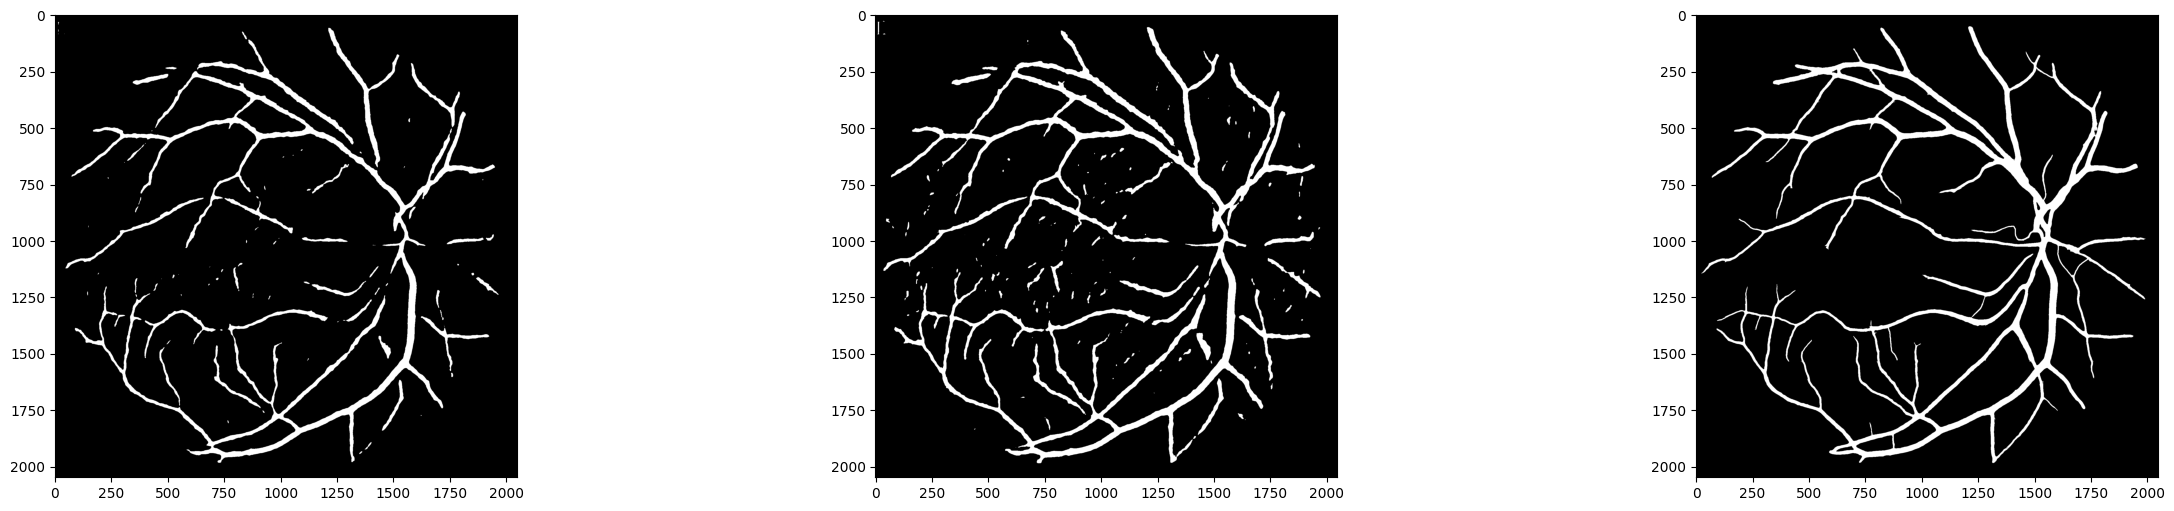

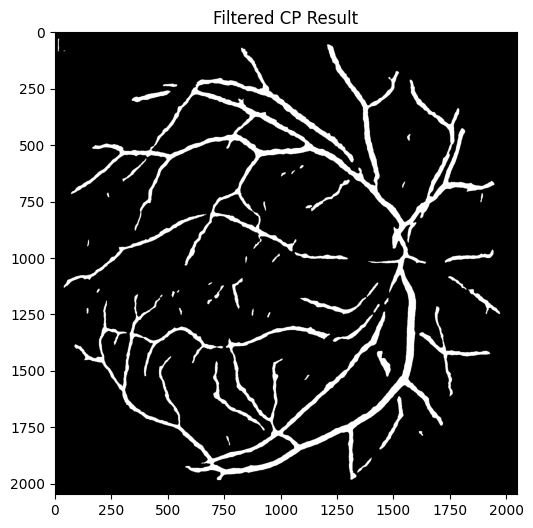

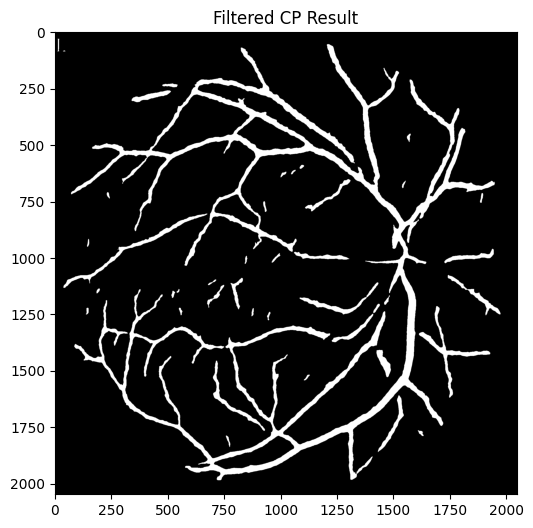

In [15]:
# 使用阈值对测试集进行推断
test_score = test_scores[:,:,random_idx]
cp_base = test_score > 0.9
cp_result = test_score > 0.3
cp_result2 = test_score > 0.1
test_mask = test_masks[:,:,random_idx]


# 绘制结果
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 6))
ax1.imshow(cp_base, cmap='gray')
ax2.imshow(cp_result2, cmap='gray')
ax3.imshow(test_mask, cmap='gray')
plt.show()



# 使用skimage处理连通分量
from skimage.measure import label

# 标记cp_result中的连通分量
labeled_result = label(cp_base)
# 标记cp_result2中的连通分量  
labeled_result1 = label(cp_result)

# 创建新的结果图
filtered_result1 = np.zeros_like(cp_result)

# 遍历cp_result2中的每个连通分量
for i in range(1, labeled_result1.max() + 1):
    # 获取当前连通分量的掩码
    component_mask = labeled_result1 == i
    
    # 检查该连通分量是否与cp_base有重叠
    if np.any(cp_base[component_mask]):
        # 如果有重叠，保留该连通分量
        filtered_result1[component_mask] = 1

# 绘制结果
plt.figure(figsize=(10, 6))
plt.imshow(filtered_result1, cmap='gray')
plt.title('Filtered CP Result')
plt.show()



# 使用skimage处理连通分量
from skimage.measure import label

# 标记cp_result中的连通分量
labeled_result = label(cp_base)
# 标记cp_result2中的连通分量  
labeled_result2 = label(cp_result2)

# 创建新的结果图
filtered_result2 = np.zeros_like(cp_result2)

# 遍历cp_result2中的每个连通分量
for i in range(1, labeled_result2.max() + 1):
    # 获取当前连通分量的掩码
    component_mask = labeled_result2 == i
    
    # 检查该连通分量是否与cp_base有重叠
    if np.any(cp_base[component_mask]):
        # 如果有重叠，保留该连通分量
        filtered_result2[component_mask] = 1

# 绘制结果
plt.figure(figsize=(10, 6))
plt.imshow(filtered_result2, cmap='gray')
plt.title('Filtered CP Result')
plt.show()


In [ ]:
# 计算cldice
import torch
import torch.nn as nn
import torch.nn.functional as F

class SoftSkeletonize(torch.nn.Module):

    def __init__(self, num_iter=40):

        super(SoftSkeletonize, self).__init__()
        self.num_iter = num_iter

    def soft_erode(self, img):

        if len(img.shape)==4:
            p1 = -F.max_pool2d(-img, (3,1), (1,1), (1,0))
            p2 = -F.max_pool2d(-img, (1,3), (1,1), (0,1))
            return torch.min(p1,p2)
        elif len(img.shape)==5:
            p1 = -F.max_pool3d(-img,(3,1,1),(1,1,1),(1,0,0))
            p2 = -F.max_pool3d(-img,(1,3,1),(1,1,1),(0,1,0))
            p3 = -F.max_pool3d(-img,(1,1,3),(1,1,1),(0,0,1))
            return torch.min(torch.min(p1, p2), p3)

    def soft_dilate(self, img):

        if len(img.shape)==4:
            return F.max_pool2d(img, (3,3), (1,1), (1,1))
        elif len(img.shape)==5:
            return F.max_pool3d(img,(3,3,3),(1,1,1),(1,1,1))

    def soft_open(self, img):
        
        return self.soft_dilate(self.soft_erode(img))

    def soft_skel(self, img):

        img1 = self.soft_open(img)
        skel = F.relu(img-img1)

        for j in range(self.num_iter):
            img = self.soft_erode(img)
            img1 = self.soft_open(img)
            delta = F.relu(img-img1)
            skel = skel + F.relu(delta - skel * delta)

        return skel

    def forward(self, img):

        return self.soft_skel(img)
class soft_cldice(nn.Module):
    def __init__(self, iter_=3, smooth = 1., exclude_background=False):
        super(soft_cldice, self).__init__()
        self.iter = iter_
        self.smooth = smooth
        self.soft_skeletonize = SoftSkeletonize(num_iter=10)
        self.exclude_background = exclude_background

    def forward(self, y_true, y_pred):
        if self.exclude_background:
            y_true = y_true[:, 1:, :, :]
            y_pred = y_pred[:, 1:, :, :]
        skel_pred = self.soft_skeletonize(y_pred)
        skel_true = self.soft_skeletonize(y_true)
        tprec = (torch.sum(torch.multiply(skel_pred, y_true))+self.smooth)/(torch.sum(skel_pred)+self.smooth)    
        tsens = (torch.sum(torch.multiply(skel_true, y_pred))+self.smooth)/(torch.sum(skel_true)+self.smooth)    
        cl_dice = 1.- 2.0*(tprec*tsens)/(tprec+tsens)
        return cl_dice


def soft_dice(y_true, y_pred):
    """[function to compute dice loss]

    Args:
        y_true ([float32]): [ground truth image]
        y_pred ([float32]): [predicted image]

    Returns:
        [float32]: [loss value]
    """
    smooth = 1
    intersection = torch.sum((y_true * y_pred))
    coeff = (2. *  intersection + smooth) / (torch.sum(y_true) + torch.sum(y_pred) + smooth)
    return (1. - coeff)


class soft_dice_cldice(nn.Module):
    def __init__(self, iter_=3, alpha=0.5, smooth = 1., exclude_background=False):
        super(soft_dice_cldice, self).__init__()
        self.iter = iter_
        self.smooth = smooth
        self.alpha = alpha
        self.soft_skeletonize = SoftSkeletonize(self.iter)
        self.exclude_background = exclude_background

    def forward(self, y_true, y_pred):
        if self.exclude_background:
            y_true = y_true[:, 1:, :, :]
            y_pred = y_pred[:, 1:, :, :]
        dice = soft_dice(y_true, y_pred)
        skel_pred = self.soft_skeletonize(y_pred)
        skel_true = self.soft_skeletonize(y_true)
        tprec = (torch.sum(torch.multiply(skel_pred, y_true))+self.smooth)/(torch.sum(skel_pred)+self.smooth)    
        tsens = (torch.sum(torch.multiply(skel_true, y_pred))+self.smooth)/(torch.sum(skel_true)+self.smooth)    
        cl_dice = 1.- 2.0*(tprec*tsens)/(tprec+tsens)
        return (1.0-self.alpha)*dice+self.alpha*cl_dice,dice,cl_dice
    
    
    
    
# 计算不同方法的cldice指标
cl_loss = soft_dice_cldice()

# 确保输入tensor的维度正确并转换为浮点类型
test_maskt = torch.from_numpy(test_mask).unsqueeze(0).unsqueeze(0) 
cp_baset = torch.from_numpy(cp_base).unsqueeze(0).unsqueeze(0) 
cp_resultt = torch.from_numpy(filtered_result1).unsqueeze(0).unsqueeze(0) 
cp_result2t = torch.from_numpy(filtered_result2).unsqueeze(0).unsqueeze(0)

# 计算基准模型的cldice
cl_base,dice,cl_dice = cl_loss(test_maskt.float(), cp_baset.float())
print("基准模型的cldice:", cl_base.item(),dice.item(),cl_dice.item())

# 计算CP方法的cldice
cp_result_loss,dice,cl_dice = cl_loss(test_maskt.float(), cp_resultt.float())
print("cp_result的cldice:", cp_result_loss.item(),dice.item(),cl_dice.item())

# 计算改进的CP方法的cldice
cp_result2_loss,dice,cl_dice = cl_loss(test_maskt.float(), cp_result2t.float())
print("cp_result2的cldice:", cp_result2_loss.item(),dice.item(),cl_dice.item())

In [ ]:
from scipy.optimize import brentq

alpha = 0.1
n = cal_scores.shape[2]
cal_gt_masks = cal_masks

alpha = 0.1
n = cal_scores.shape[2]
cal_gt_masks = cal_masks

print((n + 1) / n * alpha - 1 / n)
# Define lamhat threshold function
def lamhat_threshold(lam):
    """
    Compute the difference between FNR and target at threshold lam, used to find the optimal lamhat

    Parameters:
    - lam: current threshold value

    Returns:
    - float: the difference between FNR and target value
    """
    pred_masks = cal_scores >= lam  # Generate predicted mask using current threshold
    # flag = (cal_gt_masks == 0)
    return false_negative_rate(pred_masks, cal_gt_masks) - ((n + 1) / n * alpha - 1 / n)

# Find the optimal lamhat threshold using the brentq method
threshold_FPR = brentq(lamhat_threshold,0,1)
print(f"Calculated lamhat threshold: {threshold_FPR}")
print(threshold_FPR)






In [ ]:
print("当前的假阳率：")
print(false_positive_rate(test_scores, test_masks))

In [ ]:
# 提取mask内外的scores
scores_inside = []
scores_outside = []

# 遍历所有图片
for i in range(cal_scores.shape[2]):
    score = cal_scores[..., i]
    mask = cal_masks[..., i]
    
    scores_inside.extend(score[mask > 0].flatten())
    scores_outside.extend(score[mask == 0].flatten())

# 转换为numpy数组
scores_inside = np.array(scores_inside)
scores_outside = np.array(scores_outside)

# 创建直方图
plt.figure(figsize=(10, 6))

# 设置直方图参数
bins = 50
alpha = 0.7

# 绘制两个直方图
# 计算直方图并归一化
hist_outside, bins_outside = np.histogram(scores_outside, bins=bins, density=False)
hist_inside, bins_inside = np.histogram(scores_inside, bins=bins, density=False)

# 归一化使总和为1
hist_outside = hist_outside / np.sum(hist_outside)
hist_inside = hist_inside / np.sum(hist_inside)

# # 绘制归一化后的直方图
# plt.bar(bins_outside[:-1], hist_outside, width=np.diff(bins_outside), alpha=alpha, 
#         color='skyblue', label='Scores outside the masks')
# plt.bar(bins_inside[:-1], hist_inside, width=np.diff(bins_inside), alpha=alpha,
#         color='salmon', label='Scores inside the masks')

# 添加阈值线
plt.axvline(x=threshold_inner, color='red', linestyle='--', 
            label=f'Inner {alpha1*100}% threshold')
plt.axvline(x=threshold_outer, color='blue', linestyle='--', 
            label=f'Outer {alpha2*100}% threshold')
# 设置图表属性
plt.xlabel('scores')
plt.ylabel('normalized density (log)')
plt.title('Distribution of Scores Inside and Outside Masks')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # 设置y轴为对数刻度
plt.ylim(1e-4, 1)  # 设置y轴范围为10^-4到1

plt.tight_layout()
plt.show()

In [ ]:
# 对scores中所有像素点进行直方图统计，只统计mask外的点
scores_outside = []

# 遍历所有图片
for i in range(scores.shape[2]):
    score = scores[..., i]
    mask = gt_masks[..., i]
    
    # 只收集mask外的scores
    scores_outside.extend(score[mask == 0].flatten())

# 转换为numpy数组
scores_outside = np.array(scores_outside)

# 创建直方图
plt.figure(figsize=(10, 6))

# 设置直方图参数
bins = 50
alpha = 0.7

# 只绘制mask外的直方图
plt.hist(scores_outside, bins=bins, density=True, alpha=alpha, color='skyblue', 
         label='Scores outside the masks')

# 添加阈值线
plt.axvline(x=threshold_outer, color='blue', linestyle='--', 
            label=f'Outer {alpha1*100}% threshold')

# 设置图表属性
plt.xlabel('scores')
plt.ylabel('density')
plt.title('Distribution of Scores Outside Masks')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.5)  # 设置y轴范围为0-0.5

plt.tight_layout()
plt.show()
